In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\lavan\Downloads\social_media_analytics.csv")

In [4]:
df.drop(columns=["User ID", "Post Date"], inplace=True)

In [6]:
df["Total_Engagement"] = df["Likes"] + df["Comments"] + df["Shares"]
df["Post_Length"] = df["Post Content"].apply(len)
df["Post_Word_Count"] = df["Post Content"].apply(lambda x: len(x.split()))

In [7]:
df = pd.get_dummies(df, columns=["Platform"], drop_first=True)

In [8]:
df.drop(columns=["Post ID", "Post Content"], inplace=True)

In [9]:
X = df.drop(columns=["Total_Engagement"])
y = df["Total_Engagement"]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)


In [12]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


In [19]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("R^2 Score:", r2_score(y_true, y_pred))
    #print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))


In [20]:
evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Random Forest", y_test, rf_preds)



Linear Regression Performance:
R^2 Score: 1.0

Random Forest Performance:
R^2 Score: 0.9998526842273749


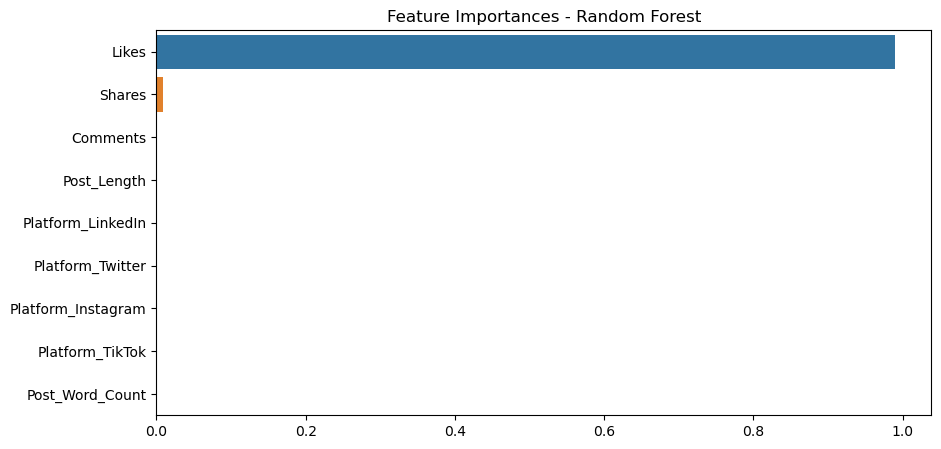

In [21]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importances.sort_values(ascending=False), y=feature_importances.sort_values(ascending=False).index)
plt.title("Feature Importances - Random Forest")
plt.show()